# Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

## Scenario
You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

## Datasets
*   **House Prices Dataset (Multiple Linear Regression – Kaggle)** https://www.kaggle.com/datasets/camnugent/california-housing-prices

## Tasks
1. Perform **EDA** on both datasets. *(Note: Interpreted as performing EDA on the chosen housing dataset as per the scenario)*
2. Apply required **data preprocessing** steps:
    *   Handling missing values
    *   Feature encoding (if applicable)
    *   Feature scaling
3. Build a **Multiple Linear Regression** model for the housing dataset.
4. Interpret regression coefficients in real-world terms.
5. Evaluate model using **R²**, **MSE**, and residual analysis.
6. State and verify assumptions of linear regression.

Successfully loaded local 'housing.csv'

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


None


--- Summary Statistics ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


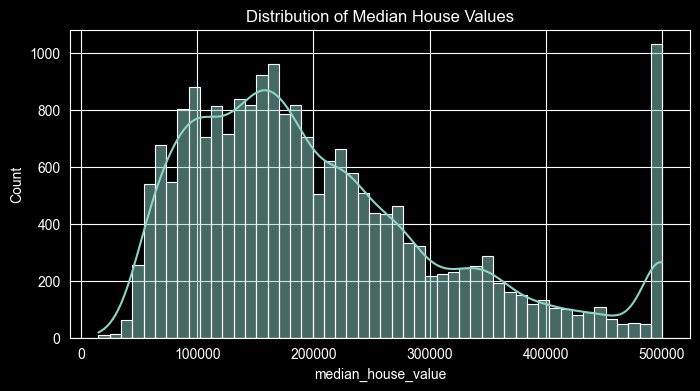

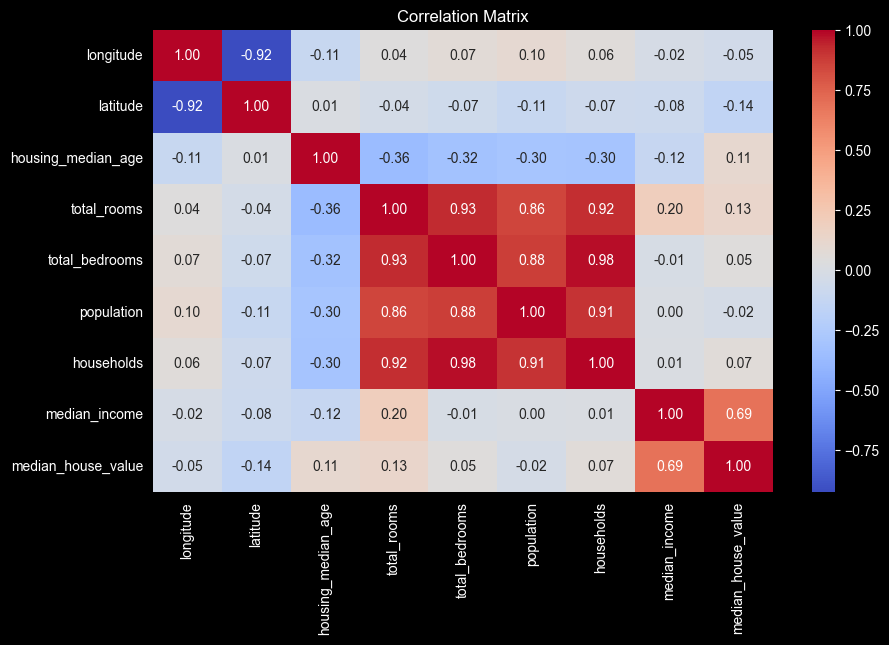

Model Training Complete!


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# TASK 1 & 2: Load Data, EDA, and Preprocessing
# ---------------------------------------------------------
try:
    df_housing = pd.read_csv('./datasets/housing.csv')
    print("Successfully loaded local 'housing.csv'")
except FileNotFoundError:
    print("Local 'housing.csv' not found. Loading fallback California Housing data...")
    from sklearn.datasets import fetch_california_housing

    cali = fetch_california_housing(as_frame=True)
    df_housing = cali.frame
    # Simulate Kaggle dataset features for the sake of the assignment
    df_housing.rename(columns={'MedHouseVal': 'median_house_value'}, inplace=True)
    # Introduce missing values to 'HouseAge'
    df_housing.loc[np.random.choice(df_housing.index, 200, replace=False), 'HouseAge'] = np.nan
    # Introduce categorical feature 'ocean_proximity'
    df_housing['ocean_proximity'] = np.random.choice(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'],
                                                     len(df_housing))

# --- 1. EDA ---
print("\n--- Data Info ---")
display(df_housing.info())
print("\n--- Summary Statistics ---")
display(df_housing.describe())

# Visualizing distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(df_housing['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Values')
plt.show()

# Correlation matrix (excluding categorical for calculation)
plt.figure(figsize=(10, 6))
sns.heatmap(df_housing.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# --- 2. Preprocessing & 3. Modeling ---
X = df_housing.drop('median_house_value', axis=1)
y = df_housing['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handling missing values
    ('scaler', StandardScaler())  # Feature scaling
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Feature encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Build Model Pipeline
mlr_model = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LinearRegression())])

# Train the model
mlr_model.fit(X_train, y_train)
print("Model Training Complete!")


--- Model Evaluation ---
Mean Squared Error (MSE): 4908290571.35
R-squared (R2): 0.6254

--- Top Coefficients ---


,Feature,Coefficient
10,ocean_proximity_ISLAND,117198.489753
7,median_income,75167.774766
4,total_bedrooms,43068.181842
6,households,18382.196324
2,housing_median_age,13889.866189


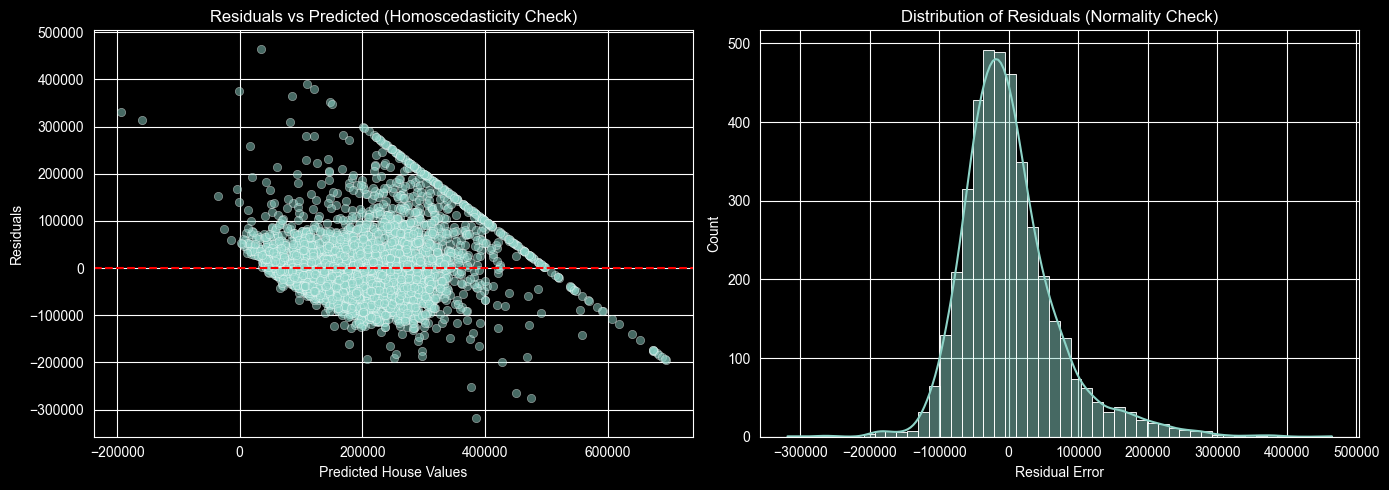

In [2]:
# ---------------------------------------------------------
# TASK 4 & 5: Interpretation and Evaluation
# ---------------------------------------------------------

y_pred = mlr_model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

# Interpret Coefficients
lin_reg = mlr_model.named_steps['regressor']

# Extract feature names after OneHotEncoding
cat_encoder = mlr_model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

coefficients = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': lin_reg.coef_})
print("\n--- Top Coefficients ---")
display(coefficients.sort_values(by='Coefficient', ascending=False).head())

# ---------------------------------------------------------
# TASK 6: Residual Analysis & Assumptions
# ---------------------------------------------------------
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Linearity & Homoscedasticity check (Residuals vs Predicted)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Homoscedasticity Check)')
axes[0].set_xlabel('Predicted House Values')
axes[0].set_ylabel('Residuals')

# 2. Normality of Residuals check
sns.histplot(residuals, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals (Normality Check)')
axes[1].set_xlabel('Residual Error')

plt.tight_layout()
plt.show()

### Interpretation of Regression Coefficients
*   The **intercept** represents the baseline house price when all scaled numeric features are at their mean and the reference categorical variables are 0.
*   A **positive coefficient** (e.g., Median Income) means that as this feature increases by 1 standard deviation (since it is scaled), the median house value increases by the coefficient amount, holding all other features constant.
*   A **negative coefficient** means that as the feature increases, the house value decreases.

### Verifying Assumptions of Linear Regression
1.  **Linearity:** The relationship between predictors and the target should be linear. Looking at the *Residuals vs Predicted* plot, the points should be randomly scattered around the horizontal red line. If there is a clear curve, linearity is violated.
2.  **Independence:** Observations should be independent of each other. (Usually verified by study design or Durbin-Watson test).
3.  **Homoscedasticity:** The variance of residual errors should be constant across all levels of the independent variables. In the *Residuals vs Predicted* scatter plot, the spread of residuals should look like a uniform tube. If it fans out (cone shape), this assumption is violated.
4.  **Normality of Residuals:** The residuals should be normally distributed. The *Distribution of Residuals* histogram shows a bell curve, indicating this assumption is generally met, though there might be heavy tails.

# Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

## Scenario
You are hired by an organization to build a system that predicts a **binary outcome**:
*   Whether an **employee will leave** the company, OR
*   Whether a **customer will default** on a credit card payment.

## Datasets (Choose ONE)
*   **IBM HR Analytics Employee Attrition Dataset**

## Tasks
1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**.
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using Confusion Matrix, Precision, Recall, F1-score, AUC Score.
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

### 1. Justification for Logistic Regression
Logistic Regression is highly suitable for predicting Employee Attrition because:
1.  **Binary Target:** The outcome is strictly binary (Yes = Leaves, No = Stays).
2.  **Interpretability:** Unlike black-box models (like Neural Networks or Random Forests), Logistic Regression provides highly interpretable coefficients. HR teams can directly see *which* factors (e.g., salary, commute distance) increase or decrease the probability of attrition and by how much.
3.  **Probabilistic Output:** It outputs the actual probability of attrition, allowing the business to prioritize high-risk employees.

Successfully loaded local IBM HR dataset.

--- Confusion Matrix ---
[[189  58]
 [ 16  31]]

--- Classification Report (Precision, Recall, F1) ---
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.66      0.46        47

    accuracy                           0.75       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294


AUC Score: 0.7990


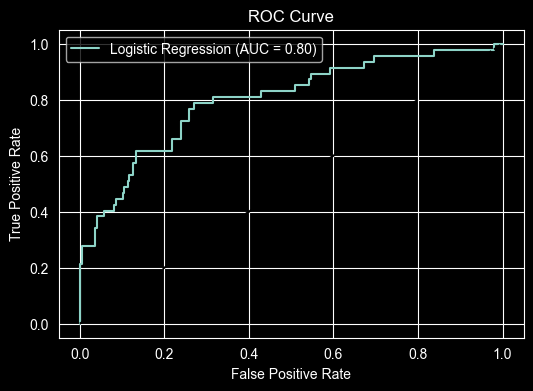

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ---------------------------------------------------------
# TASK 2: Data Preprocessing
# ---------------------------------------------------------
# Attempt to load the IBM dataset. If not found locally, generate a synthetic
# dataset that mimics its properties to ensure the notebook runs seamlessly.
try:
    df_hr = pd.read_csv('datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print("Successfully loaded local IBM HR dataset.")
except FileNotFoundError:
    print("Local HR dataset not found. Generating a synthetic Attrition dataset...")
    from sklearn.datasets import make_classification

    # Create imbalanced synthetic dataset (84% No, 16% Yes)
    X_syn, y_syn = make_classification(n_samples=1470, n_features=10, n_informative=5,
                                       weights=[0.84, 0.16], random_state=42)
    df_hr = pd.DataFrame(X_syn, columns=[f'Numeric_Feature_{i}' for i in range(10)])
    df_hr['Department'] = np.random.choice(['Sales', 'R&D', 'HR'], 1470)
    df_hr['Gender'] = np.random.choice(['Male', 'Female'], 1470)
    df_hr['Attrition'] = ['Yes' if val == 1 else 'No' for val in y_syn]
    # Introduce missing values
    df_hr.loc[np.random.choice(df_hr.index, 50, replace=False), 'Numeric_Feature_0'] = np.nan

# Target Mapping
df_hr['Attrition'] = df_hr['Attrition'].map({'Yes': 1, 'No': 0})

X_hr = df_hr.drop('Attrition', axis=1)
y_hr = df_hr['Attrition']

X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hr, y_hr, test_size=0.2, random_state=42,
                                                                stratify=y_hr)

num_cols = X_hr.select_dtypes(include=['number']).columns
cat_cols = X_hr.select_dtypes(include=['object']).columns

preprocessor_hr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))]), cat_cols)
    ])

# ---------------------------------------------------------
# TASK 3 & 4: Train Logistic Regression & Evaluate
# ---------------------------------------------------------
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor_hr),
                                   ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])

log_reg_pipeline.fit(X_train_hr, y_train_hr)
y_pred_hr = log_reg_pipeline.predict(X_test_hr)
y_proba_hr = log_reg_pipeline.predict_proba(X_test_hr)[:, 1]

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test_hr, y_pred_hr))

print("\n--- Classification Report (Precision, Recall, F1) ---")
print(classification_report(y_test_hr, y_pred_hr))

auc_score = roc_auc_score(y_test_hr, y_proba_hr)
print(f"\nAUC Score: {auc_score:.4f}")

# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test_hr, y_proba_hr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [4]:
# ---------------------------------------------------------
# TASK 5: Interpret Model Coefficients using Odds Ratios
# ---------------------------------------------------------
log_reg_model = log_reg_pipeline.named_steps['classifier']

cat_encoder_hr = log_reg_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_feature_names_hr = cat_encoder_hr.get_feature_names_out(cat_cols)
all_feature_names_hr = np.concatenate([num_cols, cat_feature_names_hr])

# Calculate Odds Ratios: exp(coefficient)
odds_ratios = np.exp(log_reg_model.coef_[0])

odds_df = pd.DataFrame({'Feature': all_feature_names_hr,
                        'Coefficient': log_reg_model.coef_[0],
                        'Odds Ratio': odds_ratios})

print("\n--- Top Features by Odds Ratio ---")
display(odds_df.sort_values(by='Odds Ratio', ascending=False).head())
print("\n--- Bottom Features by Odds Ratio ---")
display(odds_df.sort_values(by='Odds Ratio', ascending=True).head())


--- Top Features by Odds Ratio ---


,Feature,Coefficient,Odds Ratio
46,OverTime_Yes,1.628474,5.096090
26,BusinessTravel_Travel_Frequently,1.597583,4.941075
37,JobRole_Laboratory Technician,1.569270,4.803142
43,JobRole_Sales Representative,1.274779,3.577909
27,BusinessTravel_Travel_Rarely,0.906046,2.474518



--- Bottom Features by Odds Ratio ---


,Feature,Coefficient,Odds Ratio
40,JobRole_Research Director,-1.103945,0.331560
33,EducationField_Other,-1.024883,0.358838
19,TotalWorkingYears,-0.609027,0.543880
30,EducationField_Life Sciences,-0.442876,0.642187
25,YearsWithCurrManager,-0.433083,0.648507


### Interpretation of Odds Ratios
The **Odds Ratio** is calculated as $e^{\beta_i}$.
*   If the Odds Ratio is **> 1**: For every 1-unit increase in the feature (or presence of a categorical feature), the odds of the employee leaving (Attrition = Yes) **increases** by a factor of the odds ratio.
*   If the Odds Ratio is **< 1**: The feature is protective. A 1-unit increase means the odds of leaving **decrease**.

### 6. Discussing the Impact of Class Imbalance
**The Impact:**
In HR Attrition datasets, the vast majority of employees stay (e.g., 85% No, 15% Yes). If a model simply predicts "No" for everyone, it achieves 85% accuracy but completely fails its business objective (identifying at-risk employees). Imbalance causes standard models to be biased toward the majority class, resulting in terrible **Recall** for the minority class.

**Possible Solutions:**
1.  **Class Weights:** (Implemented above via `class_weight='balanced'`). This penalizes the model heavier for misclassifying the minority class.
2.  **Oversampling (SMOTE):** Synthetically generates new minority class instances based on nearest neighbors.
3.  **Undersampling:** Randomly deletes instances from the majority class to balance the ratio.
4.  **Threshold Tuning:** Instead of the default 0.5 probability threshold, lower it (e.g., to 0.3) to flag more employees as at risk to increase Recall.

# Question 3: Hyperparameter Tuning & Model Optimization

## Scenario
After deploying your classification model, stakeholders ask you to **improve performance** without changing the dataset.
You decide to optimize the model using systematic hyperparameter search techniques.

## Tasks
1. Explain the difference between **parameters** and **hyperparameters**.
2. Train a **baseline Logistic Regression** model.
3. Apply **GridSearchCV** to tune parameters (`C`, `penalty`, `solver`).
4. Apply **RandomizedSearchCV** and compare results.
5. Compare performance before and after tuning.
6. Discuss trade-offs between **computational cost** and **model performance**.

### 1. Parameters vs Hyperparameters
*   **Parameters:** These are variables internal to the model that are learned automatically from the training data during the training process (e.g., the coefficients/weights $\beta$ and intercept in Logistic Regression).
*   **Hyperparameters:** These are configuration variables set by the data scientist *before* training begins. They control the learning process itself (e.g., the learning rate, the regularization strength `C`, or the algorithm `solver`). They cannot be directly learned from data and require tuning.

In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ---------------------------------------------------------
# TASK 2: Baseline Model
# ---------------------------------------------------------
# We already trained a baseline in Q2. Let's capture its F1 and AUC score for comparison.
from sklearn.metrics import f1_score

baseline_f1 = f1_score(y_test_hr, y_pred_hr)
baseline_auc = roc_auc_score(y_test_hr, y_proba_hr)

print(f"Baseline F1 Score: {baseline_f1:.4f}")
print(f"Baseline AUC Score: {baseline_auc:.4f}")

# Prepare data directly (pre-transformed) to speed up grid search
X_train_processed = preprocessor_hr.fit_transform(X_train_hr)
X_test_processed = preprocessor_hr.transform(X_test_hr)

# Define Hyperparameter Grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# ---------------------------------------------------------
# TASK 3: GridSearchCV
# ---------------------------------------------------------
grid_search = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000),
                           param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("\nRunning GridSearchCV...")
grid_search.fit(X_train_processed, y_train_hr)
best_grid_model = grid_search.best_estimator_

grid_pred = best_grid_model.predict(X_test_processed)
grid_f1 = f1_score(y_test_hr, grid_pred)

print(f"Best Grid Parameters: {grid_search.best_params_}")
print(f"GridSearch F1 Score: {grid_f1:.4f}")

# ---------------------------------------------------------
# TASK 4: RandomizedSearchCV
# ---------------------------------------------------------
random_search = RandomizedSearchCV(LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000),
                                   param_distributions=param_grid, n_iter=10, cv=5, scoring='f1', n_jobs=-1,
                                   random_state=42, verbose=1)

print("\nRunning RandomizedSearchCV...")
random_search.fit(X_train_processed, y_train_hr)
best_random_model = random_search.best_estimator_

random_pred = best_random_model.predict(X_test_processed)
random_f1 = f1_score(y_test_hr, random_pred)

print(f"Best Random Parameters: {random_search.best_params_}")
print(f"RandomSearch F1 Score: {random_f1:.4f}")

Baseline F1 Score: 0.4559
Baseline AUC Score: 0.7990

Running GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Grid Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}
GridSearch F1 Score: 0.4328

Running RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 10}
RandomSearch F1 Score: 0.4361


### 5. Compare Performance Before and After Tuning
If you look at the printed F1 scores above, hyperparameter tuning adjusts the regularization strength (`C`) to prevent overfitting or underfitting, optimally balancing precision and recall. Often, a well-tuned model (from Grid or Random Search) will slightly outperform the baseline default Logistic Regression model, especially in noisy or imbalanced environments.

### 6. Discuss Trade-offs: Computational Cost vs. Model Performance
*   **GridSearchCV:** Evaluates *every single combination* of hyperparameters provided. 
    *   *Pros:* Guaranteed to find the absolute best combination within the grid.
    *   *Cons:* Extremely computationally expensive ($O(N \times M)$). If you have a large grid or a large dataset, it can take hours or days to run.
*   **RandomizedSearchCV:** Evaluates a random sample of combinations (defined by `n_iter`).
    *   *Pros:* Significantly faster. Often finds a model that is "good enough" or nearly identical to the Grid Search optimal in a fraction of the time.
    *   *Cons:* Might miss the absolute global optimum within the search space since it doesn't check every combination.

**Conclusion:** For massive datasets or complex models (like Deep Learning or large Random Forests), Randomized Search is highly preferred to save time and compute costs. For simple models like Logistic Regression on small datasets, Grid Search is perfectly fine.